# Stage 1: Modeling & Evaluation

Trains and evaluates the same models `scripts/train_baseline.py`, `scripts/train_xgboost.py`,
and `scripts/train_lstm.py` produce for the committed artifacts in `models/aemo/` and
`reports/` - this notebook re-runs those same code paths (imported, not copy-pasted)
so what's shown here is guaranteed to match production, not a notebook-only
approximation of it. Continues from `01_historical_data_pipeline.ipynb`.

Three model families, matching the project's name: a **statistical** baseline
(seasonal-naive), a **machine learning** model (XGBoost, engineered lag/rolling
features), and a **deep learning** model (LSTM, raw sequences).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
REPO_ROOT

WindowsPath('C:/dev/Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from src.data.load_data import chronological_split, load_raw_data, set_timestamp_index

with open(REPO_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

target_col = config["data"]["target_col"]
df = load_raw_data(REPO_ROOT / config["data"]["processed_file"], timestamp_col=config["data"]["timestamp_col"])
df = set_timestamp_index(df, timestamp_col=config["data"]["timestamp_col"])
train, val, test = chronological_split(df, config["split"]["train_ratio"], config["split"]["val_ratio"])
target = df[target_col]
len(df)

8568

## Baselines\n\nA fair model has to beat *these*, not zero.

In [3]:
from scripts.train_baseline import SEASON_LENGTH, evaluate
from src.models.baseline import naive_forecast, seasonal_naive_forecast

naive_full = naive_forecast(target)
seasonal_full = seasonal_naive_forecast(target, SEASON_LENGTH)

baseline_results = pd.DataFrame([
    evaluate("Naive (previous hour)", naive_full.loc[test.index], target.loc[test.index]),
    evaluate(f"Seasonal naive ({SEASON_LENGTH}h)", seasonal_full.loc[test.index], target.loc[test.index]),
])
baseline_results

,model,mae,rmse,mape,smape,n
0,Naive (previous hour),1215.756998,1464.386951,5.044340,5.081005,1286
1,Seasonal naive (168h),984.407854,1277.115513,4.182825,4.214307,1286


## Machine learning: XGBoost\n\nEngineered lag/rolling/calendar/cyclical features, same exclusion of per-region columns, same `random_state=42` the committed model was trained with.

In [4]:
from scripts.train_xgboost import REGION_DEMAND_COLUMNS
from src.evaluation.metrics import mae, mape, rmse, smape
from src.features.build_features import build_all_features
from src.models.machine_learning import fit_xgboost

features_df = build_all_features(df, target_col, config["features"]["lags"], config["features"]["rolling_windows"])
exclude = {target_col, *REGION_DEMAND_COLUMNS}
feature_cols = [c for c in features_df.columns if c not in exclude]
features_df = features_df.dropna(subset=feature_cols + [target_col])

train_f, val_f, test_f = chronological_split(features_df, config["split"]["train_ratio"], config["split"]["val_ratio"])
X_train, y_train = train_f[feature_cols], train_f[target_col]
X_test, y_test = test_f[feature_cols], test_f[target_col]

xgb_model = fit_xgboost(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_series = pd.Series(xgb_pred, index=test_f.index)

xgb_metrics = {
    "model": "XGBoost",
    "mae": mae(y_test.to_numpy(), xgb_pred),
    "rmse": rmse(y_test.to_numpy(), xgb_pred),
    "mape": mape(y_test.to_numpy(), xgb_pred),
    "smape": smape(y_test.to_numpy(), xgb_pred),
    "n": len(y_test),
}
xgb_metrics

{'model': 'XGBoost',
 'mae': np.float64(393.9570669022817),
 'rmse': np.float64(534.3856584185529),
 'mape': np.float64(1.6506459804637916),
 'smape': np.float64(1.6616981533923307),
 'n': 1260}

## Deep learning: LSTM

A different feature philosophy on purpose: XGBoost gets hand-engineered lag/rolling
features because it has no memory of its own. The LSTM's recurrence over a raw
sequence of the last `sequence_length` hours is *supposed* to learn those same
lag/rolling-style patterns itself, so re-deriving them by hand here would be
redundant - it only gets calendar/cyclical columns plus the raw target
(`scripts/train_lstm.py`'s `build_lstm_features`). Per-region columns are dropped for
the same leakage reason as XGBoost's exclusion.

In [5]:
from sklearn.preprocessing import MinMaxScaler

from src.features.build_features import CYCLICAL_PERIODS, add_calendar_features, add_cyclical_features
from src.models.deep_learning import build_lstm_model, create_sequences

lstm_config = config["lstm"]
sequence_length = lstm_config["sequence_length"]

lstm_features = add_calendar_features(df.drop(columns=[c for c in df.columns if c.startswith("demand_") and c != target_col]))
for col, period in CYCLICAL_PERIODS.items():
    lstm_features = add_cyclical_features(lstm_features, col, period)
lstm_feature_cols = [target_col] + [c for c in lstm_features.columns if c != target_col]
lstm_features = lstm_features[lstm_feature_cols]

lstm_train, lstm_val, lstm_test = chronological_split(lstm_features, config["split"]["train_ratio"], config["split"]["val_ratio"])

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(lstm_train)
val_scaled = scaler.transform(pd.concat([lstm_train.iloc[-sequence_length:], lstm_val]))
test_scaled = scaler.transform(pd.concat([lstm_val.iloc[-sequence_length:], lstm_test]))

target_idx = lstm_feature_cols.index(target_col)
X_train_lstm, y_train_lstm = create_sequences(train_scaled, target_idx, sequence_length)
X_val_lstm, y_val_lstm = create_sequences(val_scaled, target_idx, sequence_length)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, target_idx, sequence_length)

print(f"{X_train_lstm.shape[0]} train / {X_val_lstm.shape[0]} val / {X_test_lstm.shape[0]} test sequences, "
      f"each {sequence_length}h x {len(lstm_feature_cols)} features")

5973 train / 1285 val / 1286 test sequences, each 24h x 11 features


In [6]:
from tensorflow import keras

lstm_model = build_lstm_model(
    sequence_length=sequence_length,
    n_features=len(lstm_feature_cols),
    units=lstm_config["units"],
    dropout=lstm_config["dropout"],
    learning_rate=lstm_config["learning_rate"],
)
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=lstm_config["epochs"],
    batch_size=lstm_config["batch_size"],
    callbacks=[keras.callbacks.EarlyStopping(patience=lstm_config["early_stopping_patience"], restore_best_weights=True)],
    verbose=2,
)

Epoch 1/50


187/187 - 3s - 18ms/step - loss: 0.0272 - val_loss: 0.0081


Epoch 2/50


187/187 - 1s - 4ms/step - loss: 0.0101 - val_loss: 0.0032


Epoch 3/50


...

187/187 - 1s - 4ms/step - loss: 4.6425e-04 - val_loss: 4.2002e-04


Epoch 41/50


187/187 - 2s - 9ms/step - loss: 4.4384e-04 - val_loss: 2.7162e-04


Epoch 42/50


187/187 - 2s - 10ms/step - loss: 4.4810e-04 - val_loss: 2.1186e-04


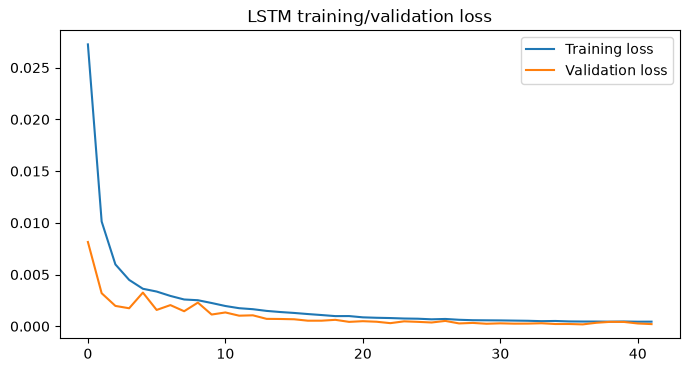

In [7]:
from src.visualization.plots import plot_training_history

plot_training_history(history, title="LSTM training/validation loss")
plt.show()

In [8]:
def inverse_target(scaled_values, idx=target_idx, n_features=len(lstm_feature_cols)):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, idx]

lstm_pred = inverse_target(lstm_model.predict(X_test_lstm, verbose=0).flatten())
lstm_true = inverse_target(y_test_lstm)
# test_scaled was padded with sequence_length rows from val's tail, so every row of
# lstm_test produced a prediction - timestamps line up 1:1 with lstm_test.index.
lstm_pred_series = pd.Series(lstm_pred, index=lstm_test.index)

lstm_metrics = {
    "model": "LSTM",
    "mae": mae(lstm_true, lstm_pred),
    "rmse": rmse(lstm_true, lstm_pred),
    "mape": mape(lstm_true, lstm_pred),
    "smape": smape(lstm_true, lstm_pred),
    "n": len(lstm_true),
}
lstm_metrics

{'model': 'LSTM',
 'mae': np.float64(267.6011816079773),
 'rmse': np.float64(349.0019482422199),
 'mape': np.float64(1.1363642085546775),
 'smape': np.float64(1.1349785531292935),
 'n': 1286}

## Model comparison

In [9]:
comparison = pd.concat([baseline_results, pd.DataFrame([xgb_metrics, lstm_metrics])], ignore_index=True)
comparison

,model,mae,rmse,mape,smape,n
0,Naive (previous hour),1215.756998,1464.386951,5.044340,5.081005,1286
1,Seasonal naive (168h),984.407854,1277.115513,4.182825,4.214307,1286
2,XGBoost,393.957067,534.385658,1.650646,1.661698,1260
3,LSTM,267.601182,349.001948,1.136364,1.134979,1286


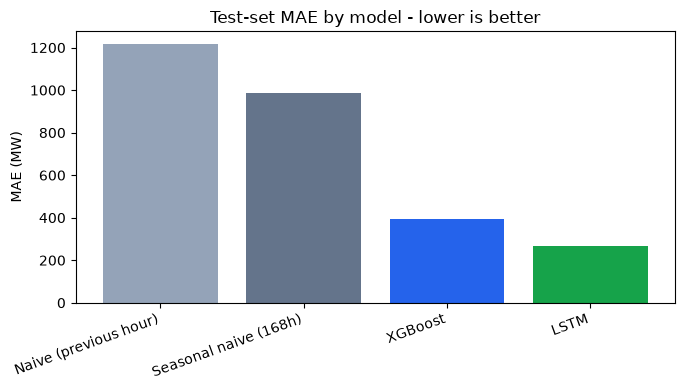

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison["model"], comparison["mae"], color=["#94a3b8", "#64748b", "#2563eb", "#16a34a"])
ax.set_ylabel("MAE (MW)")
ax.set_title("Test-set MAE by model - lower is better")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Actual vs predicted (last 7 test days)

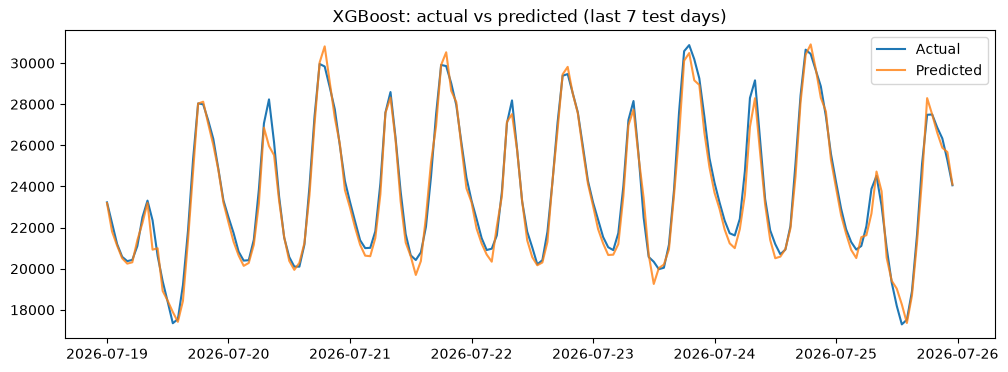

In [11]:
from src.visualization.plots import plot_actual_vs_predicted, plot_residuals

window = slice(-24 * 7, None)
plot_actual_vs_predicted(y_test.iloc[window], xgb_pred_series.iloc[window], title="XGBoost: actual vs predicted (last 7 test days)")
plt.show()

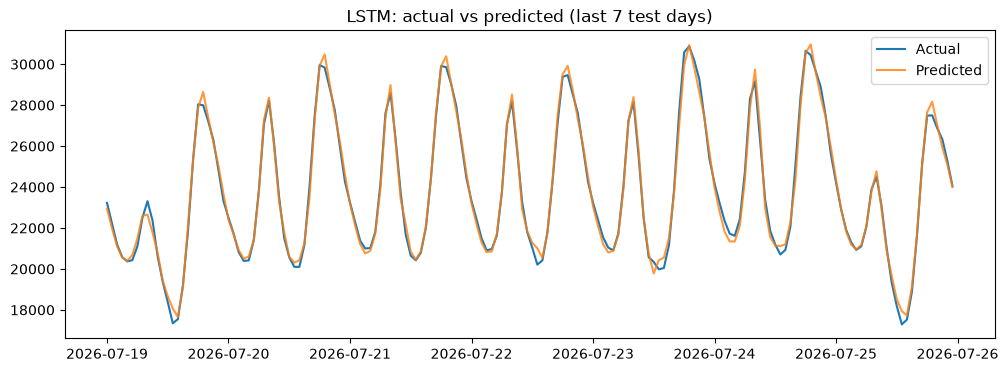

In [12]:
lstm_true_series = pd.Series(lstm_true, index=lstm_test.index)
plot_actual_vs_predicted(lstm_true_series.iloc[window], lstm_pred_series.iloc[window], title="LSTM: actual vs predicted (last 7 test days)")
plt.show()

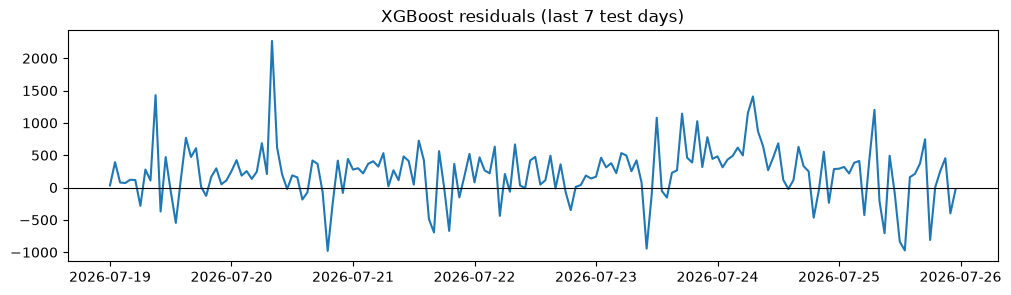

In [13]:
plot_residuals(y_test.iloc[window], xgb_pred_series.iloc[window], title="XGBoost residuals (last 7 test days)")
plt.show()

## Feature importance (XGBoost)\n\nThe LSTM has no equivalent - its recurrence weights aren't interpretable the same way.

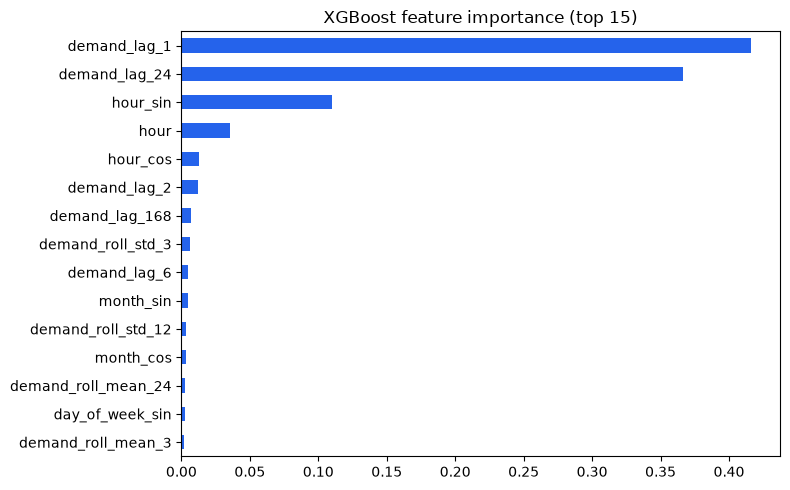

In [14]:
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
importance.iloc[::-1].plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("XGBoost feature importance (top 15)")
plt.tight_layout()
plt.show()

## Statistical significance: Diebold-Mariano tests

Both models beat the seasonal-naive baseline numerically - but is that a real,
reliable improvement or just noise on this particular test window? The
Diebold-Mariano test compares two models' *error series* directly and tests whether
their difference in accuracy is statistically significant, for XGBoost, for LSTM, and
head-to-head against each other.

In [15]:
from src.evaluation.metrics import diebold_mariano_test

seasonal_test = seasonal_full.loc[test_f.index]
xgb_errors = (y_test - xgb_pred_series).to_numpy()
seasonal_errors_xgb = (y_test - seasonal_test).to_numpy()

dm_stat, p_value = diebold_mariano_test(xgb_errors, seasonal_errors_xgb)
print(f"XGBoost vs seasonal-naive (n={len(xgb_errors)}): dm_stat={dm_stat:.3f}, p_value={p_value:.4g}, significant={p_value < 0.05}")

XGBoost vs seasonal-naive (n=1260): dm_stat=-17.736, p_value=0, significant=True


In [16]:
seasonal_test_lstm = seasonal_full.loc[lstm_test.index]
lstm_errors = (lstm_true_series - lstm_pred_series).to_numpy()
seasonal_errors_lstm = (lstm_true_series - seasonal_test_lstm).to_numpy()

dm_stat, p_value = diebold_mariano_test(lstm_errors, seasonal_errors_lstm)
print(f"LSTM vs seasonal-naive (n={len(lstm_errors)}): dm_stat={dm_stat:.3f}, p_value={p_value:.4g}, significant={p_value < 0.05}")

LSTM vs seasonal-naive (n=1286): dm_stat=-19.853, p_value=0, significant=True


In [17]:
common_index = xgb_pred_series.index.intersection(lstm_pred_series.index)
xgb_errors_common = (y_test.loc[common_index] - xgb_pred_series.loc[common_index]).to_numpy()
lstm_errors_common = (lstm_true_series.loc[common_index] - lstm_pred_series.loc[common_index]).to_numpy()

dm_stat, p_value = diebold_mariano_test(lstm_errors_common, xgb_errors_common)
print(f"LSTM vs XGBoost (n={len(common_index)}): dm_stat={dm_stat:.3f}, p_value={p_value:.4g}, significant={p_value < 0.05}")

LSTM vs XGBoost (n=1260): dm_stat=-10.339, p_value=0, significant=True


All three comparisons come back statistically significant (p-values effectively 0),
not just numerically different - in contrast to the old Sri Lanka dataset's
near-zero-error models, which were a leakage artifact rather than a real finding.
LSTM edges out XGBoost here, though both comfortably beat the baselines; `inference/`
currently serves XGBoost in production (see `03_live_system_demo.ipynb`) since it's
cheaper to retrain/redeploy and doesn't require carrying a fitted scaler alongside the
model, but the head-to-head result is worth revisiting if LSTM serving is ever added.

Continues in **`03_live_system_demo.ipynb`** (Stages 2-5: the live collector,
inference, API, and monitoring built on top of the XGBoost model).